Task 1: Construct Decision Tree models for classification and regression applications
Suggested Datasets: Pima Indians Diabetes Dataset (Classification) / Boston Housing Dataset (Regression)

Subtask 1.1: Data Acquisition and Train-Test Splits for Classification¶
Concept: Import warnings suppression parameters, load the Pima Indians Diabetes dataset, and partition features into training and test validation sets.

In [1]:
import warnings


In [2]:
warnings.filterwarnings("ignore")


In [3]:
import pandas as pd

In [4]:
from sklearn.model_selection import train_test_split

In [5]:
pima_url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

In [6]:
pima_cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

In [7]:
pima_df = pd.read_csv(pima_url, header=None, names=pima_cols)

In [8]:
X_pima = pima_df[pima_cols[:-1]]

In [9]:
y_pima = pima_df['Outcome']

In [11]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_pima, y_pima, test_size=0.20, stratify=y_pima, random_state=42
)

In [12]:
print("Pima Classification Training Set Shape:", X_train_c.shape)

Pima Classification Training Set Shape: (614, 8)


In [13]:
print("Pima Classification Test Set Shape:", X_test_c.shape)

Pima Classification Test Set Shape: (154, 8)


Subtask 1.2: Constructing the Decision Tree Classifier
Concept: Design and train a Decision Tree Classifier, restricting the max depth to prevent overfitting, and evaluate test classification metrics.

In [14]:
from sklearn.tree import DecisionTreeClassifier

In [15]:
from sklearn.metrics import accuracy_score, classification_report

In [16]:
tree_clf = DecisionTreeClassifier(max_depth=4, random_state=42)

In [17]:
tree_clf.fit(X_train_c, y_train_c)


DecisionTreeClassifier(max_depth=4, random_state=42)

In [18]:
clf_preds = tree_clf.predict(X_test_c)

In [19]:
print(f"Decision Tree Classifier Test Accuracy: {accuracy_score(y_test_c, clf_preds) * 100:.2f}%\n")

Decision Tree Classifier Test Accuracy: 79.87%



In [20]:
print("--- Classification Report ---")

--- Classification Report ---


In [21]:
print(classification_report(y_test_c, clf_preds, target_names=['No Diabetes (0)', 'Diabetes (1)']))

                 precision    recall  f1-score   support

No Diabetes (0)       0.82      0.88      0.85       100
   Diabetes (1)       0.74      0.65      0.69        54

       accuracy                           0.80       154
      macro avg       0.78      0.76      0.77       154
   weighted avg       0.80      0.80      0.80       154



Subtask 1.3: Visualizing the Trained Decision Tree Structure
Concept: Plot and inspect the trained Decision Tree structure using plot_tree to identify node thresholds, Gini impurity levels, and split paths.

In [49]:
import matplotlib.pyplot as plt

In [50]:
from sklearn.tree import plot_tree

In [51]:
plt.figure(figsize=(22,12));

<Figure size 2200x1200 with 0 Axes>

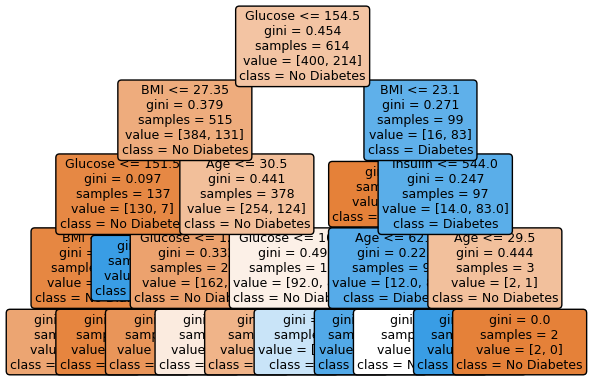

In [52]:
plot_tree(
    tree_clf,
    feature_names=pima_cols[:-1],
    class_names=['No Diabetes', 'Diabetes'],
    filled=True,
    rounded=True,
    fontsize=9
);

Text(0.5, 1.0, 'Decision Tree Classifier')

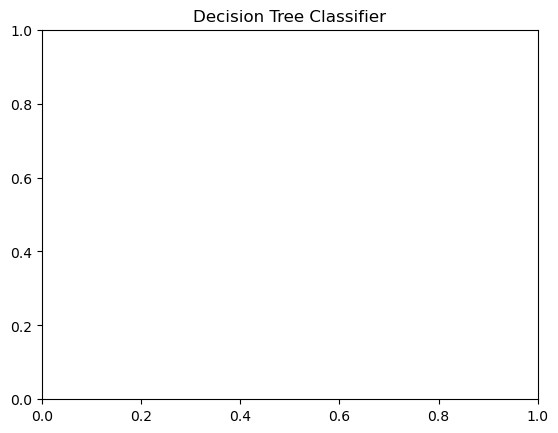

In [54]:
plt.title("Decision Tree Classifier")


In [55]:
plt.show()

Subtask 1.4: Constructing a Decision Tree Regressor
Concept: Load the Boston Housing dataset from a secure URL, split and standardize the feature space, and train a Decision Tree Regressor to predict house prices.

In [56]:
from sklearn.tree import DecisionTreeRegressor

In [57]:
from sklearn.preprocessing import StandardScaler

In [58]:
boston_url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"

In [59]:
boston_df = pd.read_csv(boston_url)

In [60]:
boston_features = [col for col in boston_df.columns if col != 'medv']

In [61]:
X_boston = boston_df[boston_features]

In [62]:
y_boston = boston_df['medv']

In [63]:
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_boston, y_boston, test_size=0.20, random_state=42)

In [64]:
scaler_r = StandardScaler()

In [65]:
X_train_r_scaled = scaler_r.fit_transform(X_train_r)

In [66]:
X_test_r_scaled = scaler_r.transform(X_test_r)


In [67]:
tree_reg = DecisionTreeRegressor(max_depth=5, random_state=42)

In [68]:
tree_reg.fit(X_train_r_scaled, y_train_r)

DecisionTreeRegressor(max_depth=5, random_state=42)

In [69]:
print("Decision Tree Regressor trained successfully. Max Depth set to 5.")

Decision Tree Regressor trained successfully. Max Depth set to 5.


Subtask 1.5: Evaluating Decision Tree Regressor Predictions
Concept: Compute continuous evaluation metrics (MSE and R2 Score) for your Decision Tree Regressor and plot actual versus predicted values.

In [70]:
from sklearn.metrics import mean_squared_error, r2_score

In [71]:
import numpy as np

In [72]:
reg_preds = tree_reg.predict(X_test_r_scaled)

In [73]:
mse_val = mean_squared_error(y_test_r, reg_preds)

In [74]:
rmse_val = np.sqrt(mse_val)

In [75]:
r2_val = r2_score(y_test_r, reg_preds)

In [76]:
print(f"Mean Squared Error (MSE): {mse_val:.4f}")

Mean Squared Error (MSE): 8.5539


In [77]:
print(f"Root Mean Squared Error (RMSE): {rmse_val:.4f} ($1000s)")

Root Mean Squared Error (RMSE): 2.9247 ($1000s)


In [78]:
print(f"R2 Coefficient of Determination: {r2_val:.4f}\n")

R2 Coefficient of Determination: 0.8834



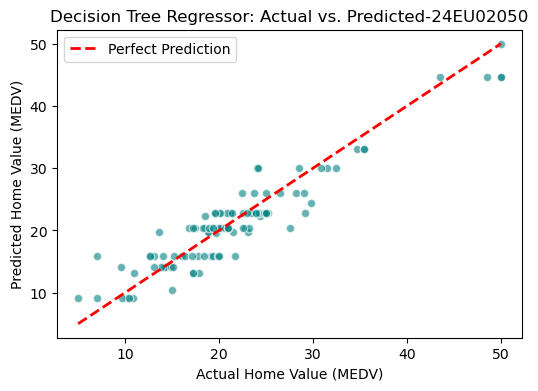

In [83]:
plt.figure(figsize=(6, 4))
plt.scatter(y_test_r, reg_preds, color='teal', alpha=0.6, edgecolor='white')
plt.plot([y_test_r.min(), y_test_r.max()], [y_test_r.min(), y_test_r.max()], 'r--', lw=2, label='Perfect Prediction')
plt.title("Decision Tree Regressor: Actual vs. Predicted-24EU02050")
plt.xlabel("Actual Home Value (MEDV)")
plt.ylabel("Predicted Home Value (MEDV)")
plt.legend()
plt.show()

Task 2: Develop ensemble learning models using Bagging, Random Forest, and Voting techniques
Suggested Dataset: Sonar Dataset

Subtask 2.1: Standard Scaling and High-Dimensional Target Map
Concept: Import warnings suppression, load the high-dimensional Sonar dataset, map targets ('M'/'R') to binary values, standardize features, and perform a stratified split.

In [94]:
import warnings

In [95]:
warnings.filterwarnings("ignore")

In [96]:
import pandas as pd 

In [97]:
from sklearn.model_selection import train_test_split

In [99]:
from sklearn.preprocessing import StandardScaler

In [104]:
# Define feature names
sonar_features = [f'Feature_{i}' for i in range(1, 61)]

In [105]:
sonar_url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/sonar.csv"

In [106]:
sonar_url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/sonar.csv"

In [107]:
sonar_columns = sonar_features + ['Class']

In [108]:
sonar_df = pd.read_csv(sonar_url, header=None, names=sonar_columns)

In [109]:
sonar_df['Class_numeric'] = sonar_df['Class'].map({'M': 1, 'R': 0})

In [110]:
X_sonar = sonar_df[sonar_features]

In [111]:
y_sonar = sonar_df['Class_numeric']

In [112]:
scaler_sonar = StandardScaler()

In [113]:
X_sonar_scaled = scaler_sonar.fit_transform(X_sonar)

In [114]:
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_sonar_scaled, y_sonar, test_size=0.30, stratify=y_sonar, random_state=42
)

In [115]:
print("Sonar Training Set Shape:", X_train_s.shape)

Sonar Training Set Shape: (145, 60)


In [116]:
print("Sonar Test Set Shape:", X_test_s.shape)

Sonar Test Set Shape: (63, 60)


Subtask 2.2: Implementing a Bagging Classifier
Concept: Train a Bagging Classifier using bootstrap aggregation on base Decision Tree estimators to reduce model variance.

In [117]:
from sklearn.ensemble import BaggingClassifier

In [118]:
from sklearn.metrics import accuracy_score

In [119]:
bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)

In [120]:
bagging_model.fit(X_train_s, y_train_s)

BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42),
                  n_estimators=50, n_jobs=-1, random_state=42)

In [121]:
bagging_preds = bagging_model.predict(X_test_s)

In [122]:
bagging_accuracy = accuracy_score(y_test_s, bagging_preds)

In [123]:
print(f"Bagging Classifier Test Accuracy: {bagging_accuracy * 100:.2f}%")

Bagging Classifier Test Accuracy: 80.95%


Subtask 2.3: Implementing a Random Forest Classifier
Concept: Train a Random Forest Classifier to observe how feature subspace selection decorrelates individual trees and controls variance.

In [124]:
from sklearn.ensemble import RandomForestClassifier

In [125]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

In [126]:
rf_model.fit(X_train_s, y_train_s)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [127]:
rf_preds = rf_model.predict(X_test_s)

In [128]:
rf_accuracy = accuracy_score(y_test_s, rf_preds)

In [129]:
print(f"Random Forest Classifier Test Accuracy: {rf_accuracy * 100:.2f}%")

Random Forest Classifier Test Accuracy: 82.54%


Subtask 2.4: Implementing a Voting Ensemble Classifier
Concept: Develop a Voting Classifier (Soft Voting) combining Logistic Regression, SVM, and a Decision Tree to establish consensus decisions.

In [130]:
from sklearn.ensemble import VotingClassifier

In [131]:
from sklearn.linear_model import LogisticRegression

In [132]:
from sklearn.svm import SVC

In [133]:
estimators = [
    ('lr', LogisticRegression(max_iter=500, random_state=42)),
    ('dt', DecisionTreeClassifier(max_depth=5, random_state=42)),
    ('svc', SVC(probability=True, random_state=42))
]


In [134]:
voting_model = VotingClassifier(estimators=estimators, voting='soft', n_jobs=-1)

In [135]:
voting_model.fit(X_train_s, y_train_s)

VotingClassifier(estimators=[('lr',
                              LogisticRegression(max_iter=500,
                                                 random_state=42)),
                             ('dt',
                              DecisionTreeClassifier(max_depth=5,
                                                     random_state=42)),
                             ('svc', SVC(probability=True, random_state=42))],
                 n_jobs=-1, voting='soft')

In [136]:
voting_preds = voting_model.predict(X_test_s)

In [137]:
voting_accuracy = accuracy_score(y_test_s, voting_preds)

In [138]:
print(f"Voting Classifier Test Accuracy: {voting_accuracy * 100:.2f}%")

Voting Classifier Test Accuracy: 87.30%


Subtask 2.5: Performance Comparison of Ensemble Techniques
Concept: Tabulate and plot a bar chart comparing test accuracies across Bagging, Random Forest, and Voting ensemble models.

In [139]:
import matplotlib.pyplot as plt

In [140]:
import seaborn as sns

In [141]:
ensemble_results = pd.DataFrame({
    'Ensemble Technique': ['Bagging (DT Base)', 'Random Forest', 'Voting Classifier (Soft)'],
    'Test Accuracy (%)': [bagging_accuracy * 100, rf_accuracy * 100, voting_accuracy * 100]
})

In [142]:
print("--- Performance Comparison ---")

--- Performance Comparison ---


In [143]:
print(ensemble_results.to_string(index=False))

      Ensemble Technique  Test Accuracy (%)
       Bagging (DT Base)          80.952381
           Random Forest          82.539683
Voting Classifier (Soft)          87.301587


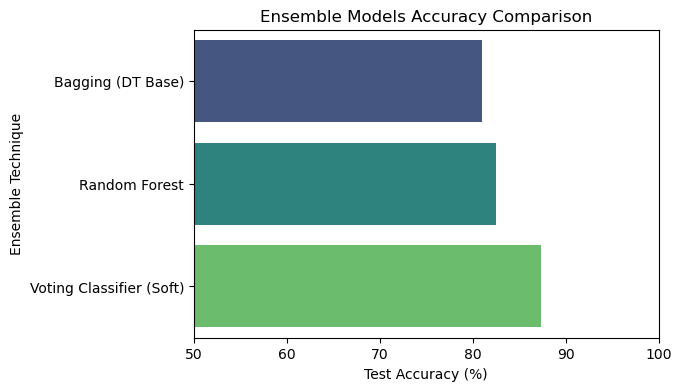

In [145]:
plt.figure(figsize=(6, 4))
sns.barplot(data=ensemble_results, x='Test Accuracy (%)', y='Ensemble Technique', palette='viridis')
plt.xlim([50, 100])
plt.title("Ensemble Models Accuracy Comparison-24EU02050")
plt.show()

Task 3: Implement and compare boosting techniques including AdaBoost and Gradient Boosting for predictive enhancement
Continuous Evaluations on Sonar Dataset

Subtask 3.1: Implementing the AdaBoost Classifier
Concept: Import warnings suppression and train an AdaBoost Classifier to observe how sequential boosting assigns higher weights to misclassified instances.

In [146]:
import warnings

In [147]:
warnings.filterwarnings("ignore")

In [148]:
from sklearn.ensemble import AdaBoostClassifier

In [149]:
from sklearn.metrics import accuracy_score

In [150]:
adaboost_model = AdaBoostClassifier(n_estimators=50, random_state=42)



In [151]:
adaboost_model.fit(X_train_s, y_train_s)

AdaBoostClassifier(random_state=42)

In [152]:
ada_preds = adaboost_model.predict(X_test_s)

In [153]:
ada_accuracy = accuracy_score(y_test_s, ada_preds)

In [154]:
print(f"AdaBoost Classifier Test Accuracy: {ada_accuracy * 100:.2f}%")

AdaBoost Classifier Test Accuracy: 82.54%


 Subtask 3.2: Implementing the Gradient Boosting Classifier
**Concept:** Train a baseline Gradient Boosting Classifier to observe sequential boosting optimization over loss function gradients.


In [155]:
from sklearn.ensemble import GradientBoostingClassifier

In [156]:
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)

In [157]:
gb_model.fit(X_train_s, y_train_s)

GradientBoostingClassifier(random_state=42)

In [158]:
gb_preds = gb_model.predict(X_test_s)

In [159]:
gb_accuracy = accuracy_score(y_test_s, gb_preds)

In [160]:
print(f"Gradient Boosting Classifier Test Accuracy: {gb_accuracy * 100:.2f}%")

Gradient Boosting Classifier Test Accuracy: 79.37%


Subtask 3.3: Hyperparameter Tuning for Gradient Boosting Classifier
**Concept:** Use GridSearchCV to tune hyperparameters (learning rate, tree count, max depth) of your Gradient Boosting Classifier to optimize model fit.

In [161]:
from sklearn.model_selection import GridSearchCV

In [162]:
param_grid = {
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 4, 5]
}


In [163]:
grid_gb = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

In [164]:
grid_gb.fit(X_train_s, y_train_s)

GridSearchCV(cv=3, estimator=GradientBoostingClassifier(random_state=42),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.05, 0.1],
                         'max_depth': [3, 4, 5],
                         'n_estimators': [50, 100, 150]},
             scoring='accuracy')

In [165]:
best_gb = grid_gb.best_estimator_

In [166]:
tuned_gb_preds = best_gb.predict(X_test_s)

In [167]:
tuned_gb_accuracy = accuracy_score(y_test_s, tuned_gb_preds)

In [168]:
print("Optimal Hyperparameters Selected:", grid_search_params := grid_gb.best_params_)

Optimal Hyperparameters Selected: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 50}


In [169]:
print(f"Tuned Gradient Boosting Test Accuracy: {tuned_gb_accuracy * 100:.2f}%")

Tuned Gradient Boosting Test Accuracy: 74.60%


Subtask 3.4: Master Comparison: Ensemble vs. Boosting Models
Concept: Create a comprehensive summary table comparing the test accuracies of all models trained in Tasks 2 and 3.

In [171]:
master_comparison = pd.DataFrame({
    'Model Classifier': [
        'Bagging Classifier', 
        'Random Forest Classifier', 
        'Voting Ensemble (Soft)', 
        'AdaBoost Classifier', 
        'Base Gradient Boosting', 
        'Tuned Gradient Boosting'
    ],
    'Accuracy (%)': [
        bagging_accuracy * 100, 
        rf_accuracy * 100, 
        voting_accuracy * 100, 
        ada_accuracy * 100, 
        gb_accuracy * 100, 
        tuned_gb_accuracy * 100
    ]
}).sort_values(by='Accuracy (%)', ascending=False)

In [172]:
print("--- Master Performance Table: Tasks 2 & 3 ---")

--- Master Performance Table: Tasks 2 & 3 ---


In [173]:
print(master_comparison.to_string(index=False))

        Model Classifier  Accuracy (%)
  Voting Ensemble (Soft)     87.301587
Random Forest Classifier     82.539683
     AdaBoost Classifier     82.539683
      Bagging Classifier     80.952381
  Base Gradient Boosting     79.365079
 Tuned Gradient Boosting     74.603175


Subtask 3.5: Plotting Feature Importances (Random Forest vs. Tuned Gradient Boosting)
Concept: Plot and compare the feature importances derived from both the Random Forest and the tuned Gradient Boosting models.

In [174]:
import matplotlib.pyplot as plt

In [175]:
import numpy as np

In [176]:
rf_importances = rf_model.feature_importances_

In [177]:
gb_importances = best_gb.feature_importances_

In [178]:
top_indices_rf = np.argsort(rf_importances)[-10:]

In [179]:
top_indices_gb = np.argsort(gb_importances)[-10:]

In [180]:
features_list = [f"F_{i}" for i in range(1, 61)]

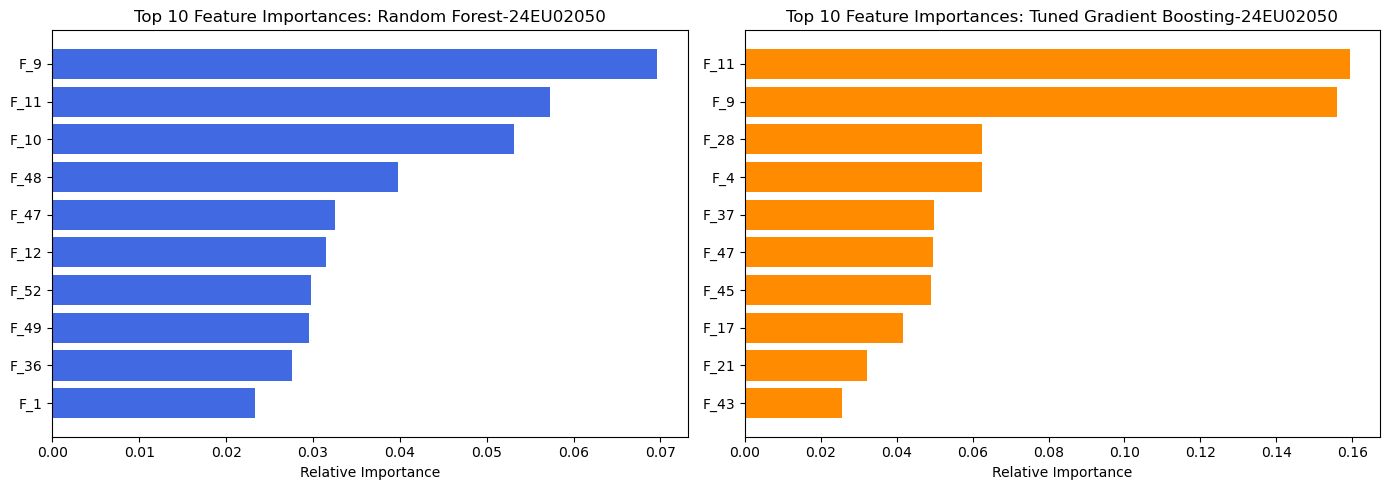

In [197]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Random Forest Importances
axes[0].barh(range(10), rf_importances[top_indices_rf], color='royalblue', align='center')
axes[0].set_yticks(range(10))
axes[0].set_yticklabels([features_list[i] for i in top_indices_rf])
axes[0].set_title("Top 10 Feature Importances: Random Forest-24EU02050")
axes[0].set_xlabel("Relative Importance")

# Plot Tuned Gradient Boosting Importances
axes[1].barh(range(10), gb_importances[top_indices_gb], color='darkorange', align='center')
axes[1].set_yticks(range(10))
axes[1].set_yticklabels([features_list[i] for i in top_indices_gb])
axes[1].set_title("Top 10 Feature Importances: Tuned Gradient Boosting-24EU02050")
axes[1].set_xlabel("Relative Importance")

plt.tight_layout()
plt.show()